# Pairwise Ranker for Learned Cache Eviction

Trains a **linear pairwise ranker** (Bradley-Terry model): given two cache items
A and B, the model predicts P(A is reused sooner than B) using a single linear
layer on the feature difference.

Since the model is linear, the pairwise probability simplifies to:

$$P(A \succ B) = \sigma(\mathbf{w}^T (\mathbf{x}_A - \mathbf{x}_B))$$

At inference time, each cached item gets a scalar priority score
$s = \mathbf{w}^T \mathbf{x}$. Evict the item with the **lowest** score.

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split
import numpy as np
import csv
import glob
from pathlib import Path

## 1. Data Loading

In [33]:
def read_csvs_to_dataframe(file_pattern: str) -> pd.DataFrame:
    """
    Reads multiple CSV files and concatenates them into a single dataframe.
    Adds a trial_id column based on the sequence in which files are loaded.
    """
    filepaths = glob.glob(file_pattern)
    dataframes = []
    for trial_id, filepath in enumerate(filepaths):
        df = pd.read_csv(filepath)
        df['trial_id'] = trial_id
        dataframes.append(df)
    combined_df = pd.concat(dataframes, ignore_index=True)
    return combined_df

df = read_csvs_to_dataframe('data/fileserver/*4_amended_access.csv')
print(f"Loaded {len(df)} rows")
df.head()

Loaded 11511970 rows


,a,t,d,i,o,s,z,f,trial_id
0,516266249654500,1555096763,253:0,786436,0,0,181829504,1000,0
1,516266249707366,1555147275,253:0,786436,1,0,181829504,1000,0
2,516266249709229,1555146903,253:0,786436,2,1,181829504,1000,0
3,516266249711042,1555146472,253:0,786436,3,1,181829504,1000,0
4,516266249712555,1555145271,253:0,786436,4,1,181829504,1000,0


## 2. Feature Discretization

In [34]:
def train_and_transform_discretizer(
    X_train: pd.DataFrame,
    n_bins: int = 5,
    encode: str = 'ordinal',
    strategy: str = 'quantile',
    subsample: int | None = None,
    random_state: int | None = None
) -> tuple[pd.DataFrame, KBinsDiscretizer]:
    discretizer = KBinsDiscretizer(
        n_bins=n_bins,
        encode=encode,
        strategy=strategy,
        subsample=subsample,
        random_state=random_state,
        quantile_method='averaged_inverted_cdf',
    )
    X_transformed = discretizer.fit_transform(X_train)
    X_transformed_df = pd.DataFrame(
        X_transformed,
        columns=X_train.columns,
        index=X_train.index
    )
    return X_transformed_df, discretizer

featureset_df, discretizer = train_and_transform_discretizer(
    df[['t', 'z', 'f']], n_bins=10, strategy='quantile'
)

n_bins_list = [len(discretizer.bin_edges_[i]) - 1 for i in range(3)]
print(f"Bins per discretized feature: {n_bins_list}")
featureset_df.describe()

Bins per discretized feature: [10, 10, 10]


,t,z,f
count,1.151197e+07,1.151197e+07,1.151197e+07
mean,4.500000e+00,4.500181e+00,4.501585e+00
std,2.872282e+00,2.872247e+00,2.871762e+00
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,2.000000e+00,2.000000e+00
50%,4.500000e+00,5.000000e+00,5.000000e+00
75%,7.000000e+00,7.000000e+00,7.000000e+00
max,9.000000e+00,9.000000e+00,9.000000e+00


## 3. One-Hot Encode Features and Build Full Feature Matrix

We precompute the one-hot expansion here so that pair generation
can work on plain numpy arrays (fast vectorized subtraction).

In [35]:
def one_hot_encode_features(discretized_df, n_bins_list):
    """
    Manually one-hot encode discretized features into a numpy array.
    
    Parameters
    ----------
    discretized_df : pd.DataFrame
        DataFrame with ordinal-encoded discretized features.
    n_bins_list : list of int
        Number of bins per feature.
    
    Returns
    -------
    np.ndarray of shape (n_samples, sum(n_bins_list))
    """
    encoded_parts = []
    for col_idx, (col_name, n_bins) in enumerate(zip(discretized_df.columns, n_bins_list)):
        col_vals = discretized_df[col_name].astype(int).values
        one_hot = np.zeros((len(col_vals), n_bins), dtype=np.float32)
        one_hot[np.arange(len(col_vals)), col_vals] = 1.0
        encoded_parts.append(one_hot)
    return np.concatenate(encoded_parts, axis=1)

# One-hot encode the 3 discretized features
X_onehot = one_hot_encode_features(featureset_df, n_bins_list)

# Append the raw features (s, trial_id)
X_raw = df[['s', 'trial_id']].values.astype(np.float32)
X_full = np.concatenate([X_onehot, X_raw], axis=1)

n_encoded_features = X_full.shape[1]
print(f"Full feature matrix shape: {X_full.shape}")
print(f"  One-hot features: {X_onehot.shape[1]} (from bins {n_bins_list})")
print(f"  Raw features: {X_raw.shape[1]} (s, trial_id)")
print(f"  Total: {n_encoded_features}")

Full feature matrix shape: (11511970, 32)
  One-hot features: 30 (from bins [10, 10, 10])
  Raw features: 2 (s, trial_id)
  Total: 32


## 4. Build Labels (Raw Next-Reuse Time)

In [36]:
Y = df.groupby(['trial_id', 'd', 'i', 'o'])['t'].shift(-1)

print(f"Label Statistics:")
print(f"  Total rows: {len(Y)}")
print(f"  Labeled rows: {Y.notna().sum()}")
print(f"  Unlabeled rows (no future match): {Y.isna().sum()}")
print(f"  Label coverage: {Y.notna().sum() / len(Y) * 100:.2f}%")

# Items with no future reuse get a very large sentinel value (= evict first)
Y.fillna(1e15, inplace=True)
Y_np = Y.values

Label Statistics:
  Total rows: 11511970
  Labeled rows: 10716133
  Unlabeled rows (no future match): 795837
  Label coverage: 93.09%


## 5. Generate Pairwise Training Data (Vectorized)

For each pair (A, B) we compute `x_A - x_B` and label:
- **1** if A is reused sooner than B
- **0** if B is reused sooner than A

All operations are vectorized with NumPy for speed.

In [37]:
def generate_pair_diffs(X_np, Y_np, n_pairs, seed=42):
    """
    Generate pairwise training data as feature differences (vectorized).
    
    Parameters
    ----------
    X_np : np.ndarray, shape (n_samples, n_features)
        Full one-hot-encoded feature matrix.
    Y_np : np.ndarray, shape (n_samples,)
        Raw next-reuse times.
    n_pairs : int
        Number of pairs to attempt generating.
    seed : int
        Random seed for reproducibility.
    
    Returns
    -------
    X_diff : np.ndarray, shape (n_valid_pairs, n_features)
        Feature differences (x_A - x_B) for each valid pair.
    labels : np.ndarray, shape (n_valid_pairs,)
        1.0 if A reused sooner, 0.0 otherwise.
    """
    rng = np.random.RandomState(seed)
    n = len(X_np)
    
    # Draw all random index pairs at once
    idx_a = rng.randint(0, n, size=n_pairs)
    idx_b = rng.randint(0, n, size=n_pairs)
    
    # Re-draw where same index was picked for both
    same = idx_a == idx_b
    while same.any():
        idx_b[same] = rng.randint(0, n, size=same.sum())
        same = idx_a == idx_b
    
    # Vectorized label computation
    y_a = Y_np[idx_a]
    y_b = Y_np[idx_b]
    
    # Filter out ties
    mask = y_a != y_b
    idx_a = idx_a[mask]
    idx_b = idx_b[mask]
    y_a = y_a[mask]
    y_b = y_b[mask]
    
    # Compute feature differences and labels in one shot
    X_diff = X_np[idx_a] - X_np[idx_b]
    labels = (y_a < y_b).astype(np.float32)
    
    return X_diff, labels

In [38]:
# Train/test split on individual samples first (no data leakage)
train_idx, test_idx = train_test_split(
    np.arange(len(X_full)), test_size=0.2, random_state=42
)

X_train_full = X_full[train_idx]
X_test_full = X_full[test_idx]
Y_train_raw = Y_np[train_idx]
Y_test_raw = Y_np[test_idx]

N_TRAIN_PAIRS = len(X_train_full) * 5
N_TEST_PAIRS = len(X_test_full) * 5

X_diff_train, Y_train_pairs = generate_pair_diffs(
    X_train_full, Y_train_raw, N_TRAIN_PAIRS, seed=42
)
X_diff_test, Y_test_pairs = generate_pair_diffs(
    X_test_full, Y_test_raw, N_TEST_PAIRS, seed=123
)

print(f"Pairwise Data Summary:")
print(f"  Encoded features per item: {n_encoded_features}")
print(f"  Training pairs: {len(Y_train_pairs)}")
print(f"  Test pairs: {len(Y_test_pairs)}")
print(f"  Train label balance (frac A sooner): {Y_train_pairs.mean():.3f}")
print(f"  Test label balance  (frac A sooner): {Y_test_pairs.mean():.3f}")

Pairwise Data Summary:
  Encoded features per item: 32
  Training pairs: 45826753
  Test pairs: 11457538
  Train label balance (frac A sooner): 0.500
  Test label balance  (frac A sooner): 0.500


## 6. Build Linear Pairwise Ranker

The model is a single `Dense(1, sigmoid)` on the feature difference vector.
This is equivalent to the Bradley-Terry model:

$$P(A \succ B) = \sigma(\mathbf{w}^T (\mathbf{x}_A - \mathbf{x}_B))$$

Note: bias is disabled since it cancels out in the difference
($\mathbf{w}^T \mathbf{x}_A + b - \mathbf{w}^T \mathbf{x}_B - b$).

In [39]:
import keras
from keras import layers
from keras.callbacks import EarlyStopping
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [40]:
input_diff = layers.Input(shape=(n_encoded_features,), name="feature_diff")
output = layers.Dense(1, activation='sigmoid', use_bias=False, name="ranking_weight")(input_diff)

model = keras.Model(inputs=input_diff, outputs=output, name="LinearPairwiseRanker")
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "LinearPairwiseRanker"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_diff (InputLayer)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ranking_weight (Dense)          │ (None, 1)              │            32 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32 (128.00 B)

 Trainable params: 32 (128.00 B)

 Non-trainable params: 0 (0.00 B)

## 7. Training

In [41]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_diff_train, Y_train_pairs,
    epochs=50,
    batch_size=256,
    validation_data=(X_diff_test, Y_test_pairs),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
179011/179011 ━━━━━━━━━━━━━━━━━━━━ 212s 1ms/step - accuracy: 0.5335 - loss: 0.6890 - val_accuracy: 0.5334 - val_loss: 0.6890
Epoch 2/50
179011/179011 ━━━━━━━━━━━━━━━━━━━━ 203s 1ms/step - accuracy: 0.5337 - loss: 0.6890 - val_accuracy: 0.5336 - val_loss: 0.6890
Epoch 3/50
179011/179011 ━━━━━━━━━━━━━━━━━━━━ 201s 1ms/step - accuracy: 0.5337 - loss: 0.6890 - val_accuracy: 0.5335 - val_loss: 0.6891
Epoch 4/50
179011/179011 ━━━━━━━━━━━━━━━━━━━━ 217s 1ms/step - accuracy: 0.5336 - loss: 0.6890 - val_accuracy: 0.5328 - val_loss: 0.6890
Epoch 5/50
179011/179011 ━━━━━━━━━━━━━━━━━━━━ 206s 1ms/step - accuracy: 0.5336 - loss: 0.6889 - val_accuracy: 0.5335 - val_loss: 0.6890
Epoch 6/50
179011/179011 ━━━━━━━━━━━━━━━━━━━━ 206s 1ms/step - accuracy: 0.5336 - loss: 0.6890 - val_accuracy: 0.5330 - val_loss: 0.6891
Epoch 7/50
179011/179011 ━━━━━━━━━━━━━━━━━━━━ 207s 1ms/step - accuracy: 0.5337 - loss: 0.6890 - val_accuracy: 0.5337 - val_loss: 0.6890
Epoch 8/50
179011/179011 ━━━━━━━━━━━━━━━━━━━━ 18

## 8. Evaluation

In [42]:
Y_pred_prob = model.predict(X_diff_test, verbose=0).ravel()
Y_pred = (Y_pred_prob >= 0.5).astype(int)
accuracy = accuracy_score(Y_test_pairs.astype(int), Y_pred)

print(f"Pairwise Test Accuracy: {accuracy:.4f}")
print(f"Trained for {len(history.history['loss'])} epochs")
print("\nClassification Report:")
print(classification_report(
    Y_test_pairs.astype(int), Y_pred,
    target_names=["B reused sooner", "A reused sooner"]
))

Pairwise Test Accuracy: 0.5336
Trained for 12 epochs

Classification Report:
                 precision    recall  f1-score   support

B reused sooner       0.53      0.53      0.53   5726694
A reused sooner       0.53      0.53      0.53   5730844

       accuracy                           0.53  11457538
      macro avg       0.53      0.53      0.53  11457538
   weighted avg       0.53      0.53      0.53  11457538



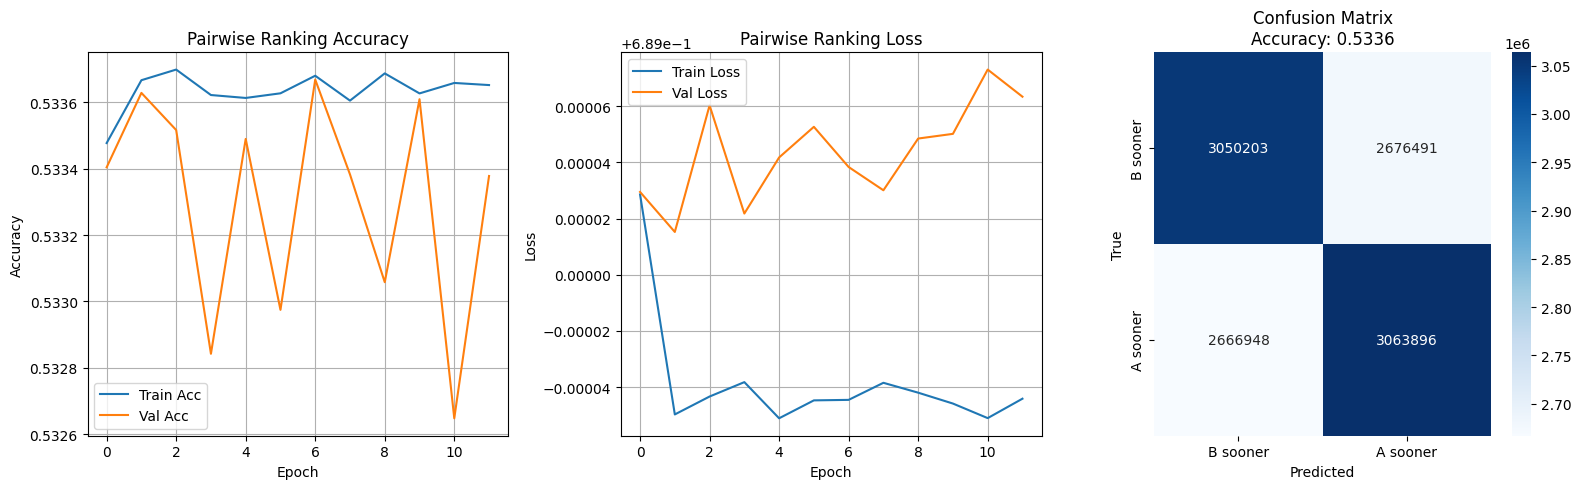

In [43]:
fig = plt.figure(figsize=(16, 5))

ax1 = plt.subplot(1, 3, 1)
ax1.plot(history.history['accuracy'], label='Train Acc')
ax1.plot(history.history['val_accuracy'], label='Val Acc')
ax1.set_title('Pairwise Ranking Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 3, 2)
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Pairwise Ranking Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

ax3 = plt.subplot(1, 3, 3)
cm = confusion_matrix(Y_test_pairs.astype(int), Y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=["B sooner", "A sooner"],
            yticklabels=["B sooner", "A sooner"])
ax3.set_title(f'Confusion Matrix\nAccuracy: {accuracy:.4f}')
ax3.set_ylabel('True')
ax3.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## 9. Extract Weight Vector for Inference

The learned weight vector $\mathbf{w}$ can be used directly to score items:

$$s_{\text{item}} = \mathbf{w}^T \mathbf{x}_{\text{item}}$$

Evict the cached block with the **lowest** score (longest predicted time to reuse).
This is just a dot product — trivial on embedded hardware.

In [44]:
# Extract the learned weight vector
w = model.get_layer('ranking_weight').get_weights()[0].ravel()
print(f"Weight vector shape: {w.shape}")
print(f"Weight vector: {w}")

# Score some test items directly with the weight vector
sample_items = X_test_full[:10]
scores = sample_items @ w  # simple dot product

print(f"\nSample item scores (higher = reused sooner = keep):")
for i, s in enumerate(scores):
    print(f"  Item {i}: score = {s:.4f}")

print(f"\nEviction order (first to evict -> last):")
order = np.argsort(scores)
print(f"  {list(order)}")

Weight vector shape: (32,)
Weight vector: [ 0.09194107  0.03403073  0.04083049  0.04504068  0.07237894  0.08015627
  0.02894653  0.0485169   0.05336409  0.04246615  0.23667282  0.19194956
  0.1957806   0.1833225   0.15777335  0.15332015  0.10893244  0.05499434
 -0.03695021 -0.24855141 -0.01296916  0.00625669 -0.03390231 -0.01729716
 -0.04214381 -0.02989745 -0.04914347 -0.03577027 -0.03969082 -0.04978727
 -0.25065327 -0.11457393]

Sample item scores (higher = reused sooner = keep):
  Item 0: score = -0.0442
  Item 1: score = -0.4880
  Item 2: score = -0.0442
  Item 3: score = -0.1887
  Item 4: score = -0.0297
  Item 5: score = -0.0656
  Item 6: score = -0.0026
  Item 7: score = -0.0734
  Item 8: score = -0.2926
  Item 9: score = -0.1678

Eviction order (first to evict -> last):
  [np.int64(1), np.int64(8), np.int64(3), np.int64(9), np.int64(7), np.int64(5), np.int64(0), np.int64(2), np.int64(4), np.int64(6)]


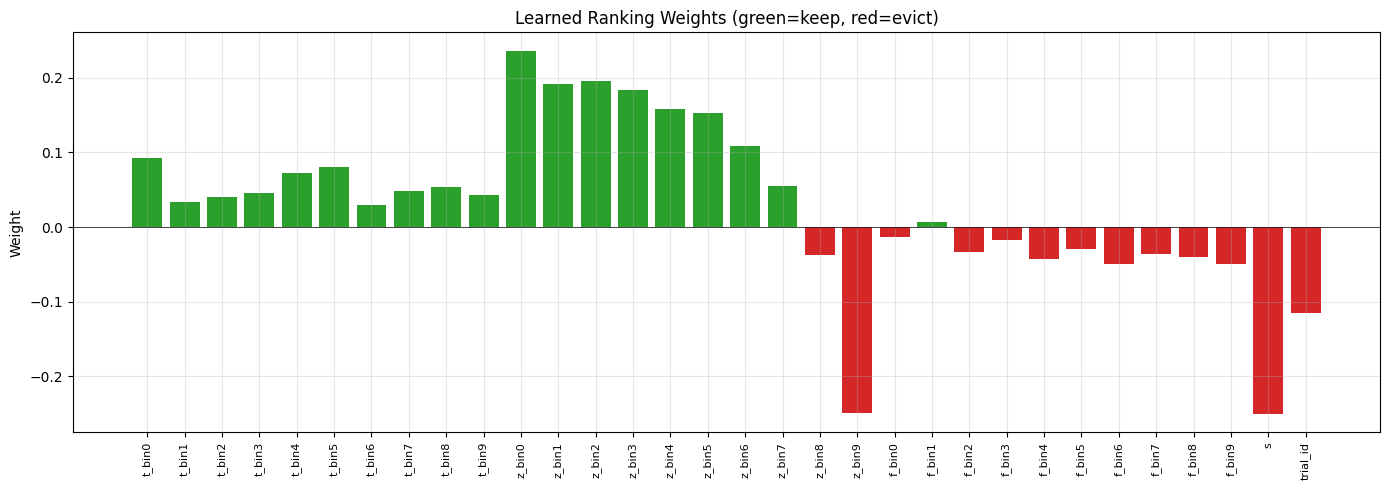

In [45]:
# Visualize feature importance (weight per one-hot bin and raw feature)
feature_names = []
for col, n_bins in zip(['t', 'z', 'f'], n_bins_list):
    for b in range(n_bins):
        feature_names.append(f"{col}_bin{b}")
feature_names.extend(['s', 'trial_id'])

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in w]
ax.bar(range(len(w)), w, color=colors)
ax.set_xticks(range(len(w)))
ax.set_xticklabels(feature_names, rotation=90, fontsize=8)
ax.set_ylabel('Weight')
ax.set_title('Learned Ranking Weights (green=keep, red=evict)')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()